# Telco Customer Churn – Exploratory Data Analysis (EDA)

In this notebook, I’m exploring the **Telco Customer Churn dataset** to understand which customer attributes drive churn
(i.e., customers leaving the service). The goal is to generate business insights that can help reduce churn and improve
customer retention.

Churn is one of the most important metrics for any subscription-based business – acquiring new customers is much more
expensive than retaining existing ones. Through EDA, I want to identify patterns such as:

- Which customer segments have the highest churn rate?
- Do contract type, tenure, or monthly charges influence churn?
- Are there early warning indicators we can use to intervene?

---

## Dataset Description

This dataset contains information about Telco's customers, their demographics, services they subscribed to,
billing details, and whether they churned or not. Here's a quick explanation of each column in plain English:

| Column | Description |
|-------|-------------|
| **customerID** | Unique identifier for each customer (not predictive). |
| **gender** | Customer's gender (Male, Female). |
| **SeniorCitizen** | Indicates if the customer is a senior citizen (1 = Yes, 0 = No). |
| **Partner** | Whether the customer has a partner (Yes/No). |
| **Dependents** | Whether the customer has dependents (Yes/No). |
| **tenure** | Number of months the customer has stayed with the company. |
| **PhoneService** | Whether the customer has a phone service (Yes/No). |
| **MultipleLines** | Whether the customer has multiple phone lines (Yes/No/No phone service). |
| **InternetService** | Type of internet service (DSL/Fiber optic/No). |
| **OnlineSecurity** | Whether the customer has online security add-on (Yes/No/No internet). |
| **OnlineBackup** | Whether the customer has online backup add-on (Yes/No/No internet). |
| **DeviceProtection** | Whether the customer has device protection add-on (Yes/No/No internet). |
| **TechSupport** | Whether the customer has tech support add-on (Yes/No/No internet). |
| **StreamingTV** | Whether the customer has streaming TV service (Yes/No/No internet). |
| **StreamingMovies** | Whether the customer has streaming movies service (Yes/No/No internet). |
| **Contract** | Type of contract (Month-to-month/One year/Two year). |
| **PaperlessBilling** | Whether the customer is on paperless billing (Yes/No). |
| **PaymentMethod** | Customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card). |
| **MonthlyCharges** | Amount charged per month (numeric). |
| **TotalCharges** | Total amount charged to the customer (numeric – may have missing or blank values). |
| **Churn** | Target variable: Yes = customer left, No = customer stayed. |

---

### Hypotheses & Business Questions

Before diving into EDA, here are some things I expect to find (hypotheses):

- **Contract type:** Customers with month-to-month contracts should churn more compared to yearly contracts.
- **Tenure:** Newer customers (low tenure) may churn at a higher rate (onboarding issue?).
- **MonthlyCharges:** Very high charges might push customers to leave (price sensitivity).
- **Senior citizens:** May have different churn patterns compared to younger customers.
- **Add-on services:** Customers with more add-ons might be "stickier" and less likely to churn.
- **Payment method:** Electronic check users might churn more if payments fail or feel inconvenient.

I’ll validate these hypotheses with visualizations and numbers in the next steps.


##  My Plan

I will:
- Handle missing values step by step
- Explore each feature individually (univariate analysis)
- Explore how each feature relates to survival (bivariate analysis)
- Engineer new features.
- Transform skewed data for better model performance
- Prepare a clean, numeric, model-ready dataset


In [ ]:
from google.colab import files
files.upload()  # Upload your kaggle.json file here

In [3]:
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 446MB/s]


In [5]:
!unzip telco-customer-churn.zip

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
# Load datset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print(f"Dataset have {df.shape[0]} rows and {df.shape[1]} columns")

Dataset have 7043 rows and 21 columns


In [9]:
# quick info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# Quick decriptive statistic for numerical cols
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [11]:
# Quick decriptive statistic for categorical cols
df.describe(include = 'object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### Observations so far

- The dataset has `(7043 rows and 21 columns)`.  
- `customerID` is unique for each customer → not useful for prediction.  
- `TotalCharges` appears as `object` → may have missing or blank values; needs cleaning.  
- Other numeric columns: `tenure`, `MonthlyCharges`, `TotalCharges`.  
- Many categorical columns: `gender`, `Partner`, `Dependents`, `PhoneService`, `Contract`, `PaymentMethod`, etc.  
- Now moving toward **missing** and **inconsistent** data .  

In [12]:
# convert 'TotalCharges' to numeric datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] ,errors='coerce')

In [13]:
# convert 'SeniorCitizen' to object datatype
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

- As found above 'TotalCharges' as object ,converted it into numerical
- As found above 'SeniorCitizen' as numeric ,converted it into object
- No other column has mismatched datatype

In [14]:
def missing_summary(df ,name) :
    """
        Return missing value summary for a given dataframe.
    """
    missing_counts = df.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending = False)
    missing_percentage =(missing_counts / len(df) * 100)
    return pd.DataFrame({
        "missing_counts" : missing_counts ,
        "missing_percentage" :missing_percentage
    }).rename_axis(f"{name}_columns")

In [15]:
# missing summary
missing_summary(df , "Dataset")

,missing_counts,missing_percentage
Dataset_columns,,
TotalCharges,11,0.156183


- The only column with missing values is TotalCharges (around 0.2% of rows) → very small, so I can impute with median or drop these few rows.
- No other columns have missing data → categorical columns are complete, which is good.
- The missing values in `TotalCharges` happen because customers with tenure = 0 have blank TotalCharges → makes sense (new customers haven’t been billed yet).
- No other columns need dropping or imputation at this stage.  

In [16]:
# Drop the missing values
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

- (since it's <0.2% of data) , I have choosen to drop those

# Univariate Analysis of Features

# Numerical columns

In [17]:
numeric_cols = df.select_dtypes(include = ['int64' ,'float64']).columns
print("Numerical columns: " ,list(numeric_cols))

Numerical columns:  ['tenure', 'MonthlyCharges', 'TotalCharges']


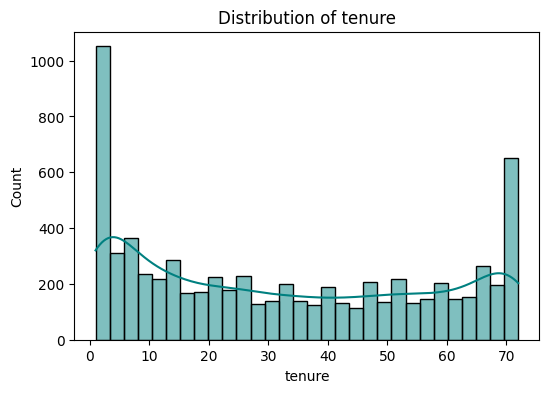

tenure stats:
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skewness: 0.23773083190513133
-----



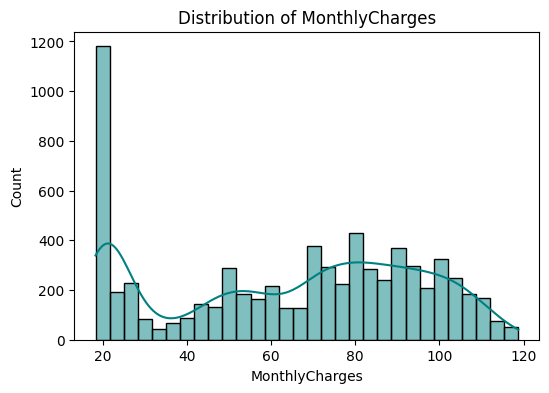

MonthlyCharges stats:
count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64
Skewness: -0.22210292770166232
-----



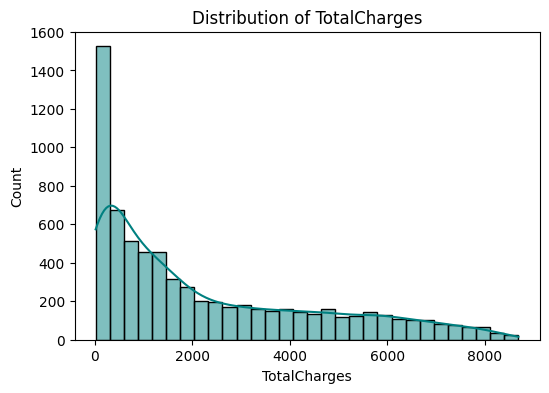

TotalCharges stats:
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64
Skewness: 0.9616424997242504
-----



In [18]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

    # Quick stats
    print(f"{col} stats:")
    print(df[col].describe())
    print("Skewness:", df[col].skew())
    print("-----\n")

- `Tenure`: Right-skewed → many new customers, few long-term ones. Could create tenure bins later.
- `MonthlyCharges`: Fairly spread, slight right skew → some high-paying customers.
- `TotalCharges`: Very similar to Monthly × Tenure, right-skewed; may need log-transform for modeling if using algorithms sensitive to scale/skew.

# Categorical Columns

In [19]:
cat_cols = df.select_dtypes('object').columns
print("Categorical columns :" ,list(cat_cols))

Categorical columns : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [25]:
def get_column_summary(df, columns, id_cols=None):
    """
    Displays value counts, percentages, countplots, and churn %
    for a list of categorical columns.

    Parameters:
    df : DataFrame
        The dataset to analyze
    columns : list
        List of categorical columns to summarize
    id_cols : list
        Columns to skip (like IDs)
    """
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (6,4)

    # Remove ID columns if provided
    if id_cols:
        columns = [col for col in columns if col not in id_cols]

    for col in columns:
        print("-------------" * 5)
        summary_df = pd.DataFrame({
            f"{col}_counts": df[col].value_counts(),
            f"{col}_percentage": df[col].value_counts() / len(df[col]) * 100
        })
        print(f"{col} value counts & percentage")
        display(summary_df)

        # countplot
        sns.countplot(x=col, hue=col, data=df, palette='Set2', legend=False)
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)
        plt.show()

        churn_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        print(f"Churn % by {col}")
        display(churn_pct)

-----------------------------------------------------------------
gender value counts & percentage


,gender_counts,gender_percentage
gender,,
Male,3549,50.469283
Female,3483,49.530717


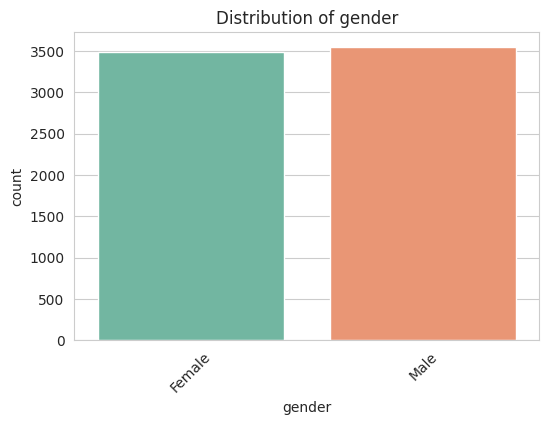

Churn % by gender


Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


-----------------------------------------------------------------
SeniorCitizen value counts & percentage


,SeniorCitizen_counts,SeniorCitizen_percentage
SeniorCitizen,,
0,5890,83.759954
1,1142,16.240046


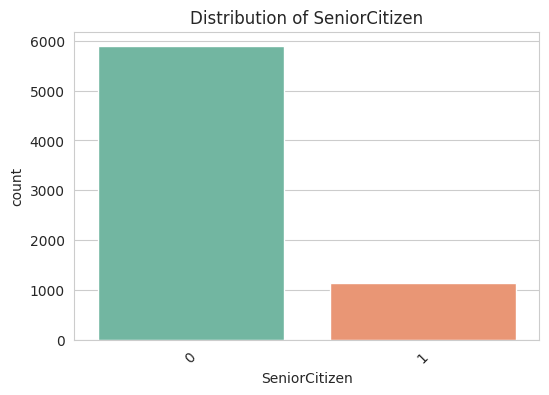

Churn % by SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


-----------------------------------------------------------------
Partner value counts & percentage


,Partner_counts,Partner_percentage
Partner,,
No,3639,51.749147
Yes,3393,48.250853


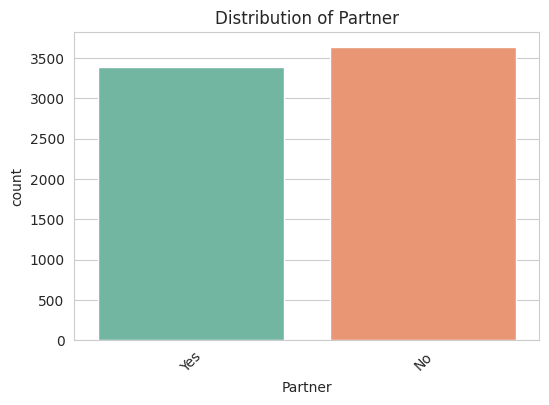

Churn % by Partner


Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


-----------------------------------------------------------------
Dependents value counts & percentage


,Dependents_counts,Dependents_percentage
Dependents,,
No,4933,70.150739
Yes,2099,29.849261


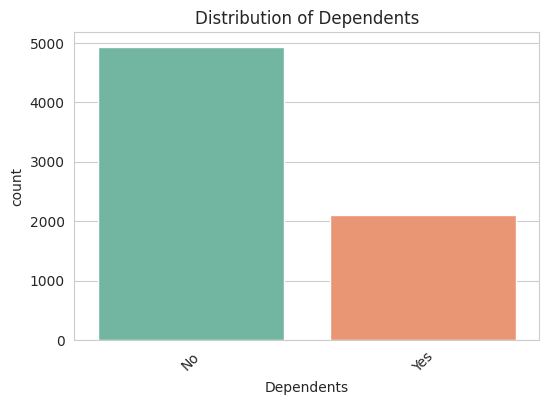

Churn % by Dependents


Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


-----------------------------------------------------------------
PhoneService value counts & percentage


,PhoneService_counts,PhoneService_percentage
PhoneService,,
Yes,6352,90.32992
No,680,9.67008


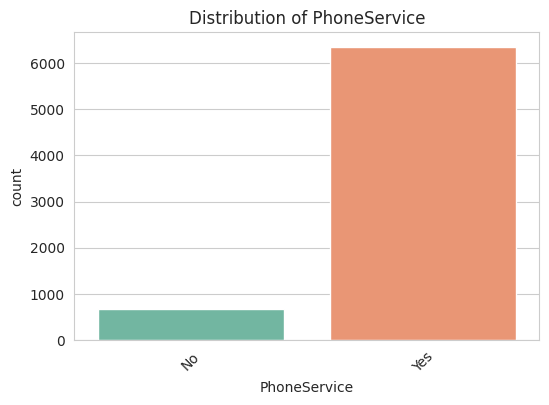

Churn % by PhoneService


Churn,No,Yes
PhoneService,,
No,75.000000,25.000000
Yes,73.252519,26.747481


-----------------------------------------------------------------
MultipleLines value counts & percentage


,MultipleLines_counts,MultipleLines_percentage
MultipleLines,,
No,3385,48.137088
Yes,2967,42.192833
No phone service,680,9.670080


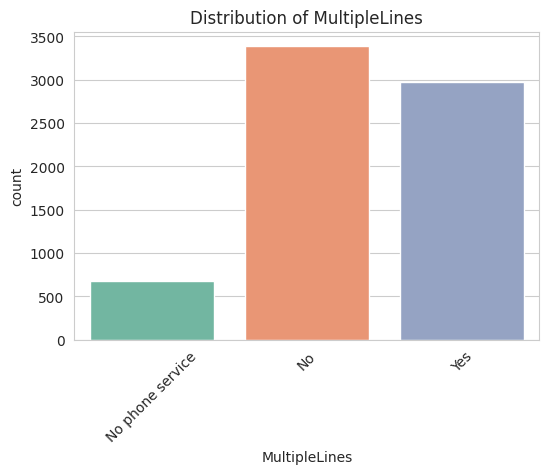

Churn % by MultipleLines


Churn,No,Yes
MultipleLines,,
No,74.918759,25.081241
No phone service,75.000000,25.000000
Yes,71.351534,28.648466


-----------------------------------------------------------------
InternetService value counts & percentage


,InternetService_counts,InternetService_percentage
InternetService,,
Fiber optic,3096,44.027304
DSL,2416,34.357224
No,1520,21.615472


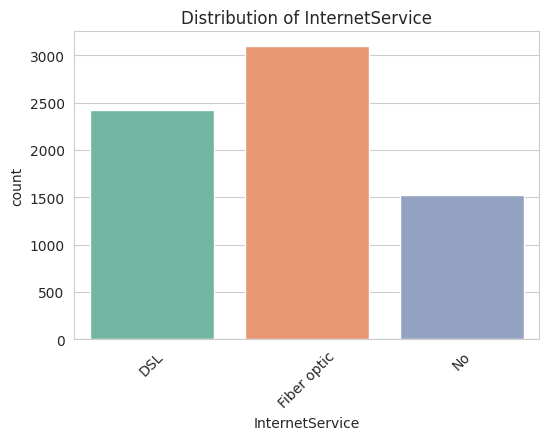

Churn % by InternetService


Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


-----------------------------------------------------------------
OnlineSecurity value counts & percentage


,OnlineSecurity_counts,OnlineSecurity_percentage
OnlineSecurity,,
No,3497,49.729807
Yes,2015,28.654721
No internet service,1520,21.615472


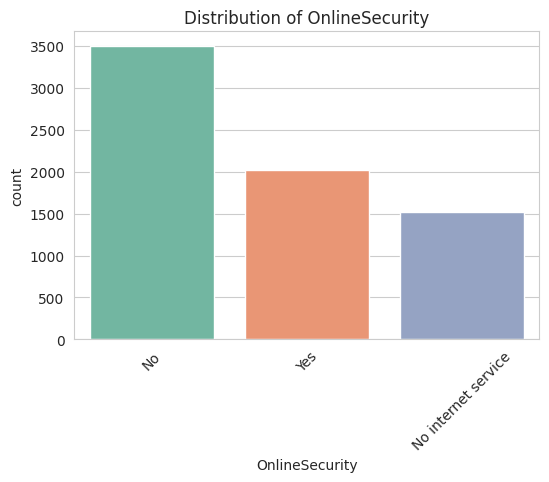

Churn % by OnlineSecurity


Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


-----------------------------------------------------------------
OnlineBackup value counts & percentage


,OnlineBackup_counts,OnlineBackup_percentage
OnlineBackup,,
No,3087,43.899317
Yes,2425,34.485210
No internet service,1520,21.615472


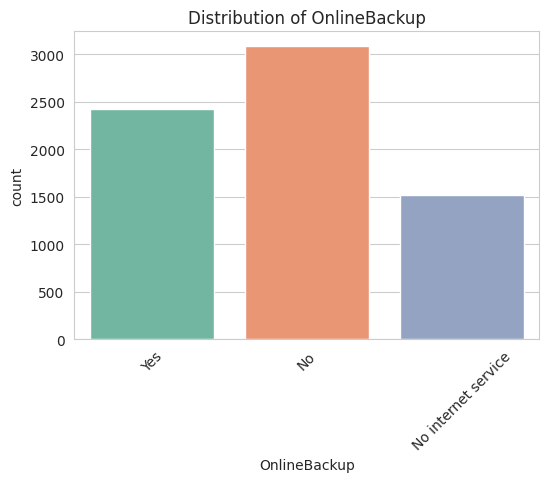

Churn % by OnlineBackup


Churn,No,Yes
OnlineBackup,,
No,60.058309,39.941691
No internet service,92.565789,7.434211
Yes,78.432990,21.567010


-----------------------------------------------------------------
DeviceProtection value counts & percentage


,DeviceProtection_counts,DeviceProtection_percentage
DeviceProtection,,
No,3094,43.998862
Yes,2418,34.385666
No internet service,1520,21.615472


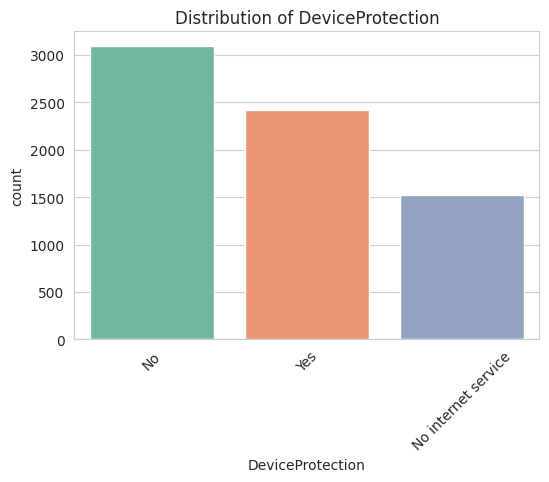

Churn % by DeviceProtection


Churn,No,Yes
DeviceProtection,,
No,60.859729,39.140271
No internet service,92.565789,7.434211
Yes,77.460711,22.539289


-----------------------------------------------------------------
TechSupport value counts & percentage


,TechSupport_counts,TechSupport_percentage
TechSupport,,
No,3472,49.374289
Yes,2040,29.010239
No internet service,1520,21.615472


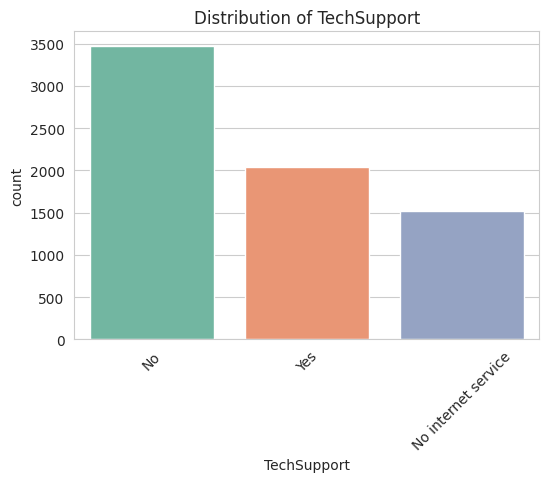

Churn % by TechSupport


Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


-----------------------------------------------------------------
StreamingTV value counts & percentage


,StreamingTV_counts,StreamingTV_percentage
StreamingTV,,
No,2809,39.945961
Yes,2703,38.438567
No internet service,1520,21.615472


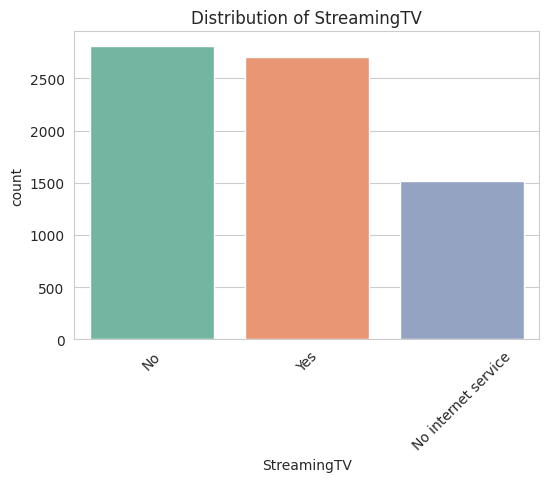

Churn % by StreamingTV


Churn,No,Yes
StreamingTV,,
No,66.464934,33.535066
No internet service,92.565789,7.434211
Yes,69.885313,30.114687


-----------------------------------------------------------------
StreamingMovies value counts & percentage


,StreamingMovies_counts,StreamingMovies_percentage
StreamingMovies,,
No,2781,39.547782
Yes,2731,38.836746
No internet service,1520,21.615472


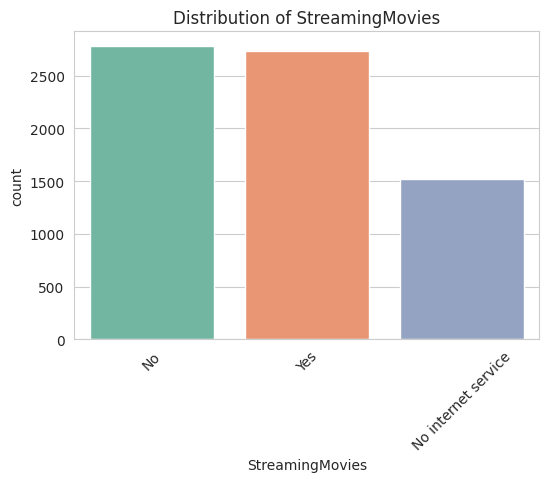

Churn % by StreamingMovies


Churn,No,Yes
StreamingMovies,,
No,66.271125,33.728875
No internet service,92.565789,7.434211
Yes,70.047602,29.952398


-----------------------------------------------------------------
Contract value counts & percentage


,Contract_counts,Contract_percentage
Contract,,
Month-to-month,3875,55.105233
Two year,1685,23.961889
One year,1472,20.932878


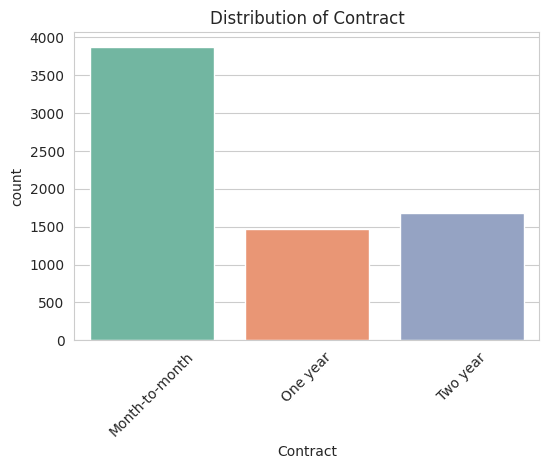

Churn % by Contract


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


-----------------------------------------------------------------
PaperlessBilling value counts & percentage


,PaperlessBilling_counts,PaperlessBilling_percentage
PaperlessBilling,,
Yes,4168,59.2719
No,2864,40.7281


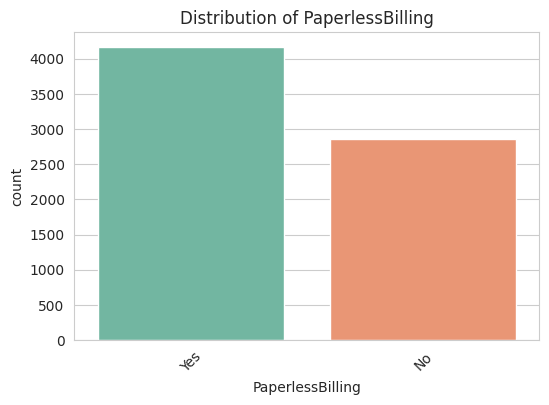

Churn % by PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


-----------------------------------------------------------------
PaymentMethod value counts & percentage


,PaymentMethod_counts,PaymentMethod_percentage
PaymentMethod,,
Electronic check,2365,33.631968
Mailed check,1604,22.810011
Bank transfer (automatic),1542,21.928328
Credit card (automatic),1521,21.629693


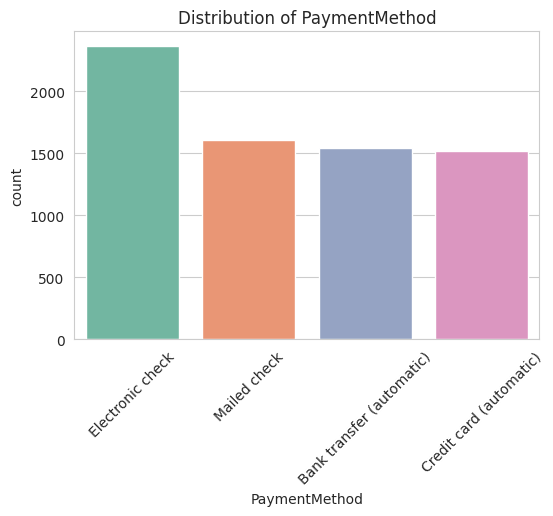

Churn % by PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


-----------------------------------------------------------------
Churn value counts & percentage


,Churn_counts,Churn_percentage
Churn,,
No,5163,73.421502
Yes,1869,26.578498


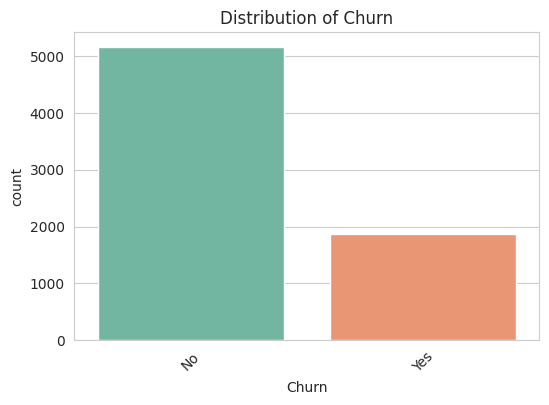

Churn % by Churn


Churn,No,Yes
Churn,,
No,100.0,0.0
Yes,0.0,100.0


In [29]:
# Univariate analysis for categorical columns
get_column_summary(df ,cat_cols ,'customerID')

- `Contract type`: Month-to-month customers have highest churn → company should target with retention campaigns.
- `Payment method`: Electronic check users churn more → possible friction or convenience issue.
- `SeniorCitizen`: Slightly higher churn → opportunity for senior-friendly plans/support.
- `Family-related features (Partner, Dependents)`: Presence reduces churn → family customers are “stickier.”
- `Add-on services (OnlineSecurity, TechSupport, Streaming, etc.)`: Customers with more services churn less → cross-sell & bundle upsell opportunities.
- `Gender`: Minimal effect on churn → no targeted action needed.

## Outlier Detection and Handling

In [32]:
# Function for outlier detection
def detect_outliers(df , feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    #Inter-quartile range
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound ) | (df[feature] > upper_bound)]
    print(f"{feature} : {outliers.shape[0]} outliers detected ")
    return outliers , lower_bound ,upper_bound

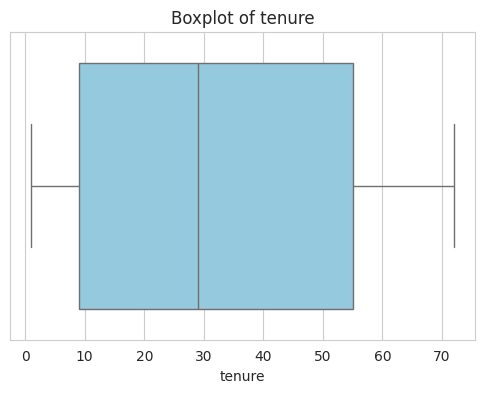

tenure : 0 outliers detected 
tenure → Lower Bound: -60.00, Upper Bound: 124.00
Found 0 outliers (0.00% of data)



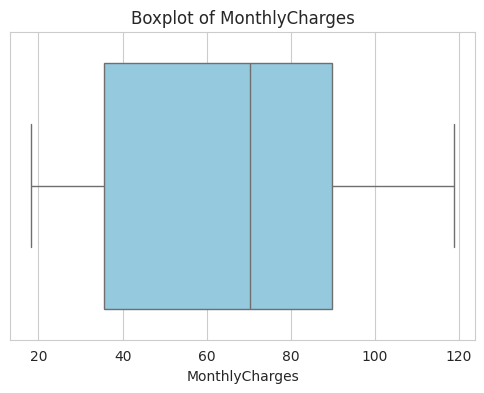

MonthlyCharges : 0 outliers detected 
MonthlyCharges → Lower Bound: -45.82, Upper Bound: 171.27
Found 0 outliers (0.00% of data)



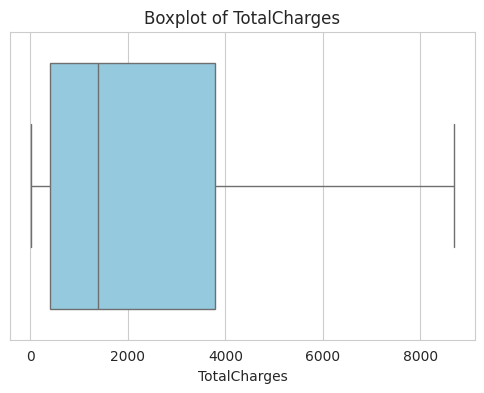

TotalCharges : 0 outliers detected 
TotalCharges → Lower Bound: -4688.48, Upper Bound: 8884.67
Found 0 outliers (0.00% of data)



In [41]:
# Plot boxplots + check outliers for each numeric column
for col in numeric_cols:
    sns.boxplot(x=df[col], color= 'skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

    outliers, lb, ub = detect_outliers(df, col)
    print(f"{col} → Lower Bound: {lb:.2f}, Upper Bound: {ub:.2f}")
    print(f"Found {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}% of data)\n")


- Tenure: No outliers detected → all customers have tenure within a reasonable range (0–72 months).
- MonthlyCharges: No outliers detected → charges distribution is consistent with real plans.
- TotalCharges: No outliers detected → total revenue per customer is within realistic bounds.
- I don't need to remove or cap any data points — retained all rows for analysis.

# Bivariate Analysis (Categorical × Churn)


In [46]:
# Function to calculate churn percentage for a categorical column
def churn_percentage_table(df, col):
    return pd.crosstab(df[col], df['Churn'], normalize='index') * 100


----------------------------------------------------------------------


Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


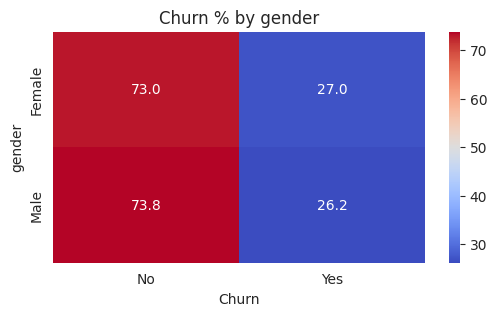

 Gender has little effect on churn → no targeted action needed here.

----------------------------------------------------------------------


Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


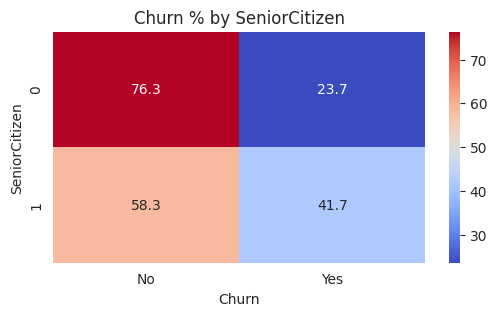

 Seniors have slightly higher churn → consider senior-friendly plans or better customer support experience.

----------------------------------------------------------------------


Churn,No,Yes
Partner,,
No,67.02,32.98
Yes,80.28,19.72


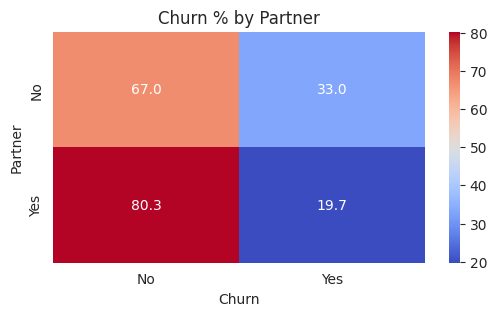

 Customers with partner churn less → family support may increase loyalty, could market 'family bundles'.

----------------------------------------------------------------------


Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.47,15.53


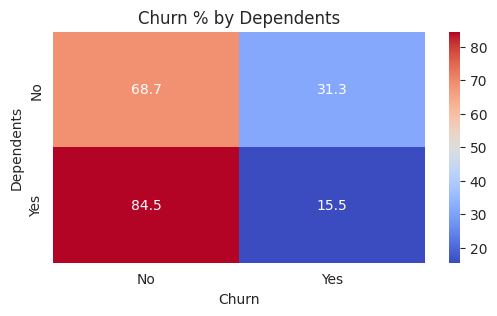

 Customers with dependents churn less → family support may increase loyalty, could market 'family bundles'.

----------------------------------------------------------------------


Churn,No,Yes
PhoneService,,
No,75.00,25.00
Yes,73.25,26.75


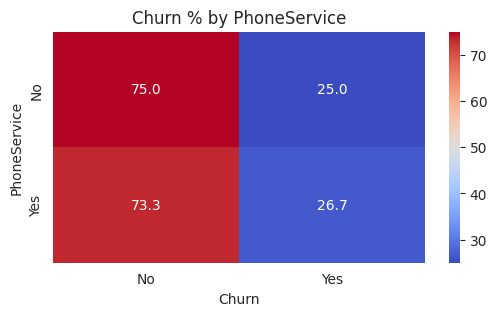

----------------------------------------------------------------------


Churn,No,Yes
MultipleLines,,
No,74.92,25.08
No phone service,75.00,25.00
Yes,71.35,28.65


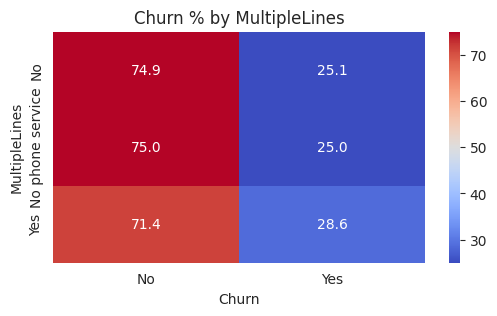

----------------------------------------------------------------------


Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


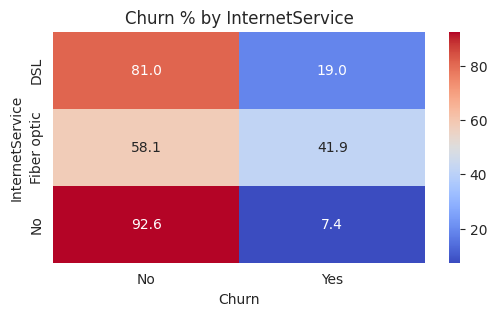

 Customers without InternetService churn more → bundling these services might reduce churn.

----------------------------------------------------------------------


Churn,No,Yes
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


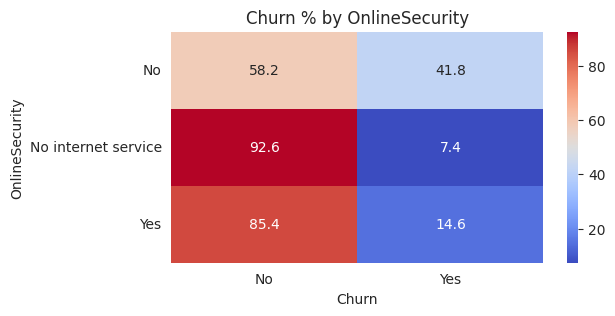

 Customers without OnlineSecurity churn more → bundling these services might reduce churn.

----------------------------------------------------------------------


Churn,No,Yes
OnlineBackup,,
No,60.06,39.94
No internet service,92.57,7.43
Yes,78.43,21.57


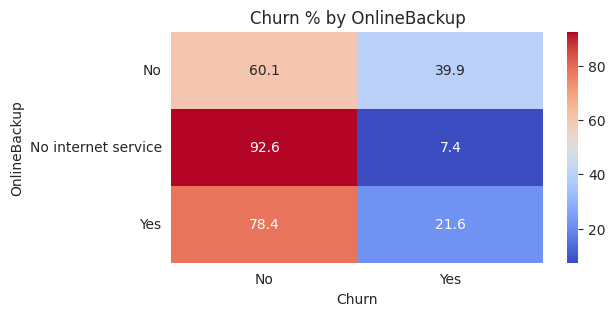

 Customers without OnlineBackup churn more → bundling these services might reduce churn.

----------------------------------------------------------------------


Churn,No,Yes
DeviceProtection,,
No,60.86,39.14
No internet service,92.57,7.43
Yes,77.46,22.54


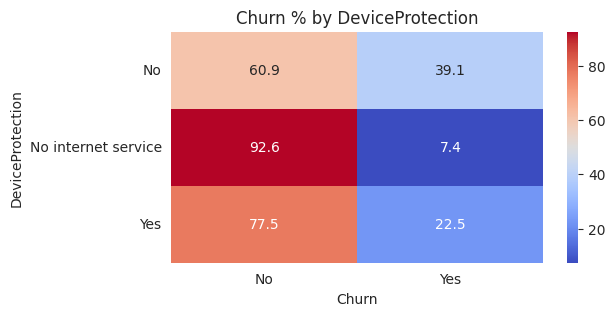

 Customers without DeviceProtection churn more → bundling these services might reduce churn.

----------------------------------------------------------------------


Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


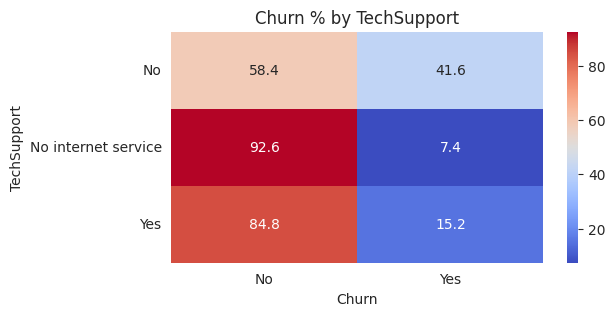

 Customers without TechSupport churn more → bundling these services might reduce churn.

----------------------------------------------------------------------


Churn,No,Yes
StreamingTV,,
No,66.46,33.54
No internet service,92.57,7.43
Yes,69.89,30.11


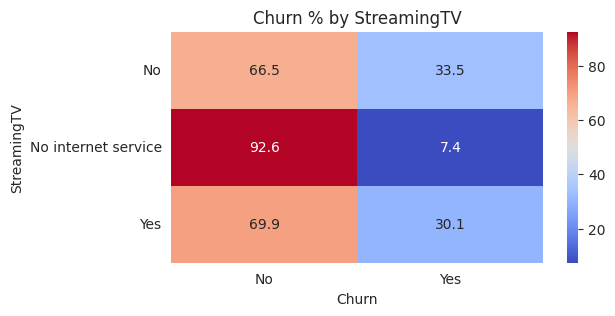

 Customers without StreamingTV churn more → bundling these services might reduce churn.

----------------------------------------------------------------------


Churn,No,Yes
StreamingMovies,,
No,66.27,33.73
No internet service,92.57,7.43
Yes,70.05,29.95


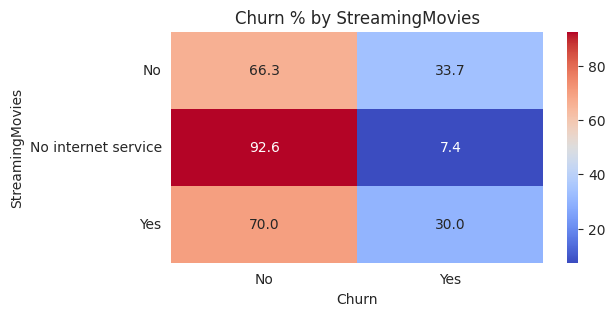

 Customers without StreamingMovies churn more → bundling these services might reduce churn.

----------------------------------------------------------------------


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


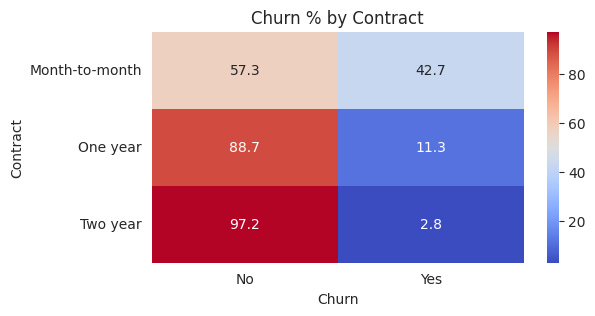

 Month-to-month customers have the HIGHEST churn → strong case for loyalty programs or discounted annual plans.

----------------------------------------------------------------------


Churn,No,Yes
PaperlessBilling,,
No,83.62,16.38
Yes,66.41,33.59


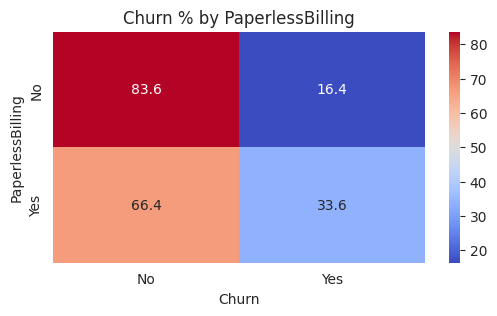

 Slightly higher churn for paperless billing customers → might be correlated with payment method (electronic check).

----------------------------------------------------------------------


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


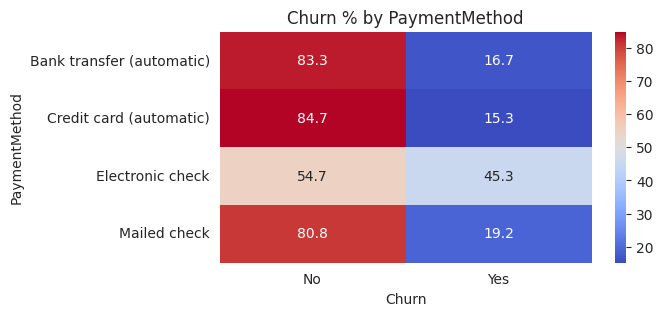

 Electronic check users churn significantly more → investigate if payment experience is frustrating or error-prone.

----------------------------------------------------------------------


Churn,No,Yes
Churn,,
No,100.0,0.0
Yes,0.0,100.0


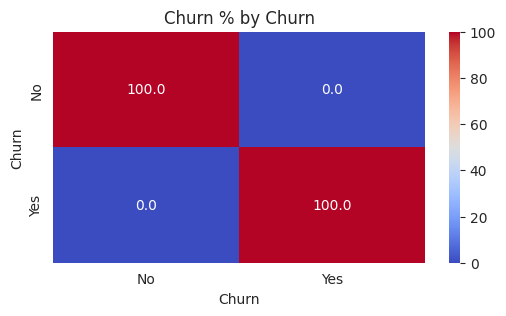

In [51]:
# Heatmap + churn percentage for each categorical column
for col in cat_cols[1::]:
    print("--------------" * 5)
    churn_pct = churn_percentage_table(df, col)
    display(churn_pct.round(2))

    plt.figure(figsize=(6,3))
    sns.heatmap(churn_pct, annot=True, cmap="coolwarm", fmt=".1f")
    plt.title(f'Churn % by {col}')
    plt.ylabel(col)
    plt.xlabel('Churn')
    plt.show()

    # Inference
    if col == 'Contract':
        print(" Month-to-month customers have the HIGHEST churn → strong case for loyalty programs or discounted annual plans.\n")
    elif col == 'PaymentMethod':
        print(" Electronic check users churn significantly more → investigate if payment experience is frustrating or error-prone.\n")
    elif col == 'SeniorCitizen':
        print(" Seniors have slightly higher churn → consider senior-friendly plans or better customer support experience.\n")
    elif col in ['Partner', 'Dependents']:
        print(f" Customers with {col.lower()} churn less → family support may increase loyalty, could market 'family bundles'.\n")
    elif col in ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']:
        print(f" Customers without {col} churn more → bundling these services might reduce churn.\n")
    elif col == 'PaperlessBilling':
        print(" Slightly higher churn for paperless billing customers → might be correlated with payment method (electronic check).\n")
    elif col == 'gender':
        print(" Gender has little effect on churn → no targeted action needed here.\n")
